<a href="https://colab.research.google.com/github/gravity102424/ESAA/blob/main/0515_%EC%84%B8%EC%85%98_%EC%8B%9C%EA%B3%84%EC%97%B4_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **OB 시계열 연습문제**


AAPL(Apple Inc.)의 주가 데이터를 이용하여, 과거 60일의 종가 데이터를 입력으로 받아 다음 날의 주가를 예측하는 LSTM 모델을 구현하고 예측 결과를 시각화해봅시다.🚀

### 0. 필요 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# device 설정: 가능하면 GPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1. 데이터 다운로드 및 전처리

1-a. yfinance 라이브러리를 사용해 AAPL(Apple Inc.)의 주가 데이터를 2010년 1월 1일부터 2023년 1월 1일까지 다운로드하세요. 다운로드한 데이터에서 'Close' 컬럼만 선택하고, 결측치를 제거하세요.

힌트: yf.download(ticker, start, end) 함수를 사용합니다.


In [2]:
# 데이터 로드
df = yf.download('AAPL', start='2010-01-01', end='2023-01-01')

# Close 칼럼만 선택
df_close = df[['Close']]

# 결측치 제거
df_clean = df_close.dropna()

/tmp/ipykernel_15006/4292542638.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2010-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


1-b. MinMaxScaler를 이용해 데이터를 0~1 범위로 정규화하세요.

In [3]:
# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_clean)

### 2. 시퀀스 데이터 생성

정규화된 데이터를 바탕으로, 슬라이딩 윈도우 기법을 사용하여 지난 60일의 데이터를 입력 시퀀스로, 61번째 날의 데이터를 타깃으로 하는 시퀀스 데이터셋을 생성하세요.

힌트: for 루프를 활용해 인덱스를 이동하면서 각 시퀀스를 구성합니다. 시퀀스 데이터 생성 함수를 정의해 사용할 수 있습니다.

In [4]:
# 2. 시퀀스 데이터 생성 함수 (예: 지난 60일을 보고 다음 날 예측)
def create_sequences(data, window_size=60):
    X = []
    y = []

    # 전체 데이터 길이에서 window_size만큼 뺀 범위까지 반복
    for i in range(window_size, len(data)):
        # i-window_size부터 i 이전까지의 데이터를 입력(X)으로 설정
        X.append(data[i-window_size:i, 0])
        # i번째 데이터를 타깃(y)으로 설정
        y.append(data[i, 0])

    return np.array(X), np.array(y)

# 데이터 생성 (윈도우 사이즈: 60)
window_size = 60
X, y = create_sequences(scaled_data, window_size)

# LSTM 입력을 위해 3차원으로 변형 (samples, time_steps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

### 3. 데이터셋 분할 및 Pytorch 텐서로 변환

3-a. 생성한 시퀀스 데이터를 학습용(80%)과 테스트용(20%)으로 분리하세요.

In [5]:
# 데이터셋을 학습용과 테스트용으로 분리 (80% 학습, 20% 테스트)
total_samples = len(X)
train_size = int(total_samples * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

3-b. 분리한 데이터를 PyTorch 텐서(torch.FloatTensor)로 변환하고, 타깃 데이터의 차원도 (batch_size, 1)로 맞추세요.

In [6]:
# 3. PyTorch 텐서로 변환
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

In [7]:
# 타깃 텐서의 차원 변경: (batch_size, 1)
y_train_tensor = y_train_tensor.view(-1, 1)
y_test_tensor = y_test_tensor.view(-1, 1)

### 4. LSTM 모델 정의

PyTorch를 이용해 LSTM 모델을 구현하세요.
모델은 하나 이상의 LSTM 레이어와 최종 출력을 위한 Fully Connected(FC) 레이어로 구성되어야 합니다.
순전파(forward) 함수에서 초기 hidden state와 cell state를 올바르게 초기화하세요.

힌트: 교재 p.414 내용 참고

In [8]:
# 4. LSTM 모델 정의

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM 레이어 정의
        # batch_first=True: 입력 데이터의 형태가 (batch, seq, feature)임을 의미합니다.
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # 최종 출력을 위한 Fully Connected 레이어
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # 1. 초기 hidden state와 cell state를 0으로 초기화
        # (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # 2. LSTM 통과
        # out: 각 시점의 hidden state 출력값
        # (hn, cn): 마지막 시점의 hidden state와 cell state
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # 3. 마지막 시점의 hidden state(out[:, -1, :])를 FC 레이어에 전달
        # 많은 시퀀스 중 가장 마지막(최신) 정보를 바탕으로 다음 날 주가를 예측합니다.
        out = self.fc(out[:, -1, :])

        return out

# 모델 파라미터 설정
input_size = 1   # 피처 개수 (종가 1개)
hidden_size = 64 # 은닉 상태의 크기 (사용자 지정)
num_layers = 2   # LSTM 레이어를 쌓는 층수
output_size = 1  # 출력값 (예측 주가 1개)

# 모델 생성
model = LSTMModel(input_size, hidden_size, num_layers, output_size)
print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### 5. 모델학습

5-a. 모델학습에 필요한 변수 값들(criterion, optimizer, num_epochs 등)을 정의하세요. (시간 상 epoch수는 30으로 하는 것을 추천합니다.)

In [11]:
# 손실함수와 옵티마이저 정의

import torch.optim as optim

criterion = nn.MSELoss()
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 30
train_hist = []

5-b. 정의한 LSTM 모델을 사용해 학습을 진행하세요.학습 과정에서 MSELoss를 손실함수로, Adam Optimizer를 최적화 도구로 사용하세요.

In [12]:
# 모델 학습
for epoch in range(num_epochs):
    model.train() # 모델을 학습 모드로 설정

    # 1. Gradient 초기화
    # 이전 루프에서 계산된 기울기를 초기화해야 새로운 기울기가 올바르게 계산됩니다.
    optimizer.zero_grad()

    # 2. Forward pass (순전파)
    # 모델에 데이터를 입력하여 예측값을 얻습니다.
    outputs = model(X_train_tensor)

    # 3. 손실 계산
    # 예측값과 실제 정답(y) 사이의 오차를 계산합니다.
    loss = criterion(outputs, y_train_tensor)

    # 4. Backward pass (역전파) 및 가중치 업데이트
    # 오차를 바탕으로 기울기를 계산하고 최적화 도구가 모델 파라미터를 수정합니다.
    loss.backward()
    optimizer.step()

    # 학습 과정 기록
    train_hist.append(loss.item())

    # 5. 진행 상황 출력
    # 5 에폭마다 손실 값을 출력하여 학습이 잘 되고 있는지 확인합니다.
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

Epoch [5/30], Loss: 0.008657
Epoch [10/30], Loss: 0.007777
Epoch [15/30], Loss: 0.006506
Epoch [20/30], Loss: 0.003949
Epoch [25/30], Loss: 0.000104
Epoch [30/30], Loss: 0.000314


### 6. 예측 결과 시각화

테스트 데이터를 활용하여 모델의 예측을 수행한 후, 예측 결과와 실제 주가를 비교하는 그래프를 작성하세요.
예측 결과와 실제 값은 정규화된 값이므로, scaler.inverse_transform을 사용해 원래 주가 값으로 복원해야 합니다.

힌트: 모델 예측 시 GPU를 사용했다면 .cpu().detach().numpy()를 통해 NumPy 배열로 변환하세요.


In [13]:
# 테스트 데이터에 대한 예측
model.eval() # 평가 모드로 전환 (Dropout이나 Batch Normalization 등이 비활성화됨)
with torch.no_grad(): # 평가 시에는 기울기 계산이 필요 없으므로 메모리 절약
    test_predict = model(X_test_tensor)
# 텐서를 numpy 배열로 변환 (GPU 사용 시 .cpu() 필요)
test_predict_np = test_predict.cpu().detach().numpy()
y_test_np = y_test_tensor.cpu().detach().numpy()

In [14]:
# 정규화 복원: 실제 주가로 변환

test_predict_real = scaler.inverse_transform(test_predict_np)
y_test_real = scaler.inverse_transform(y_test_np)

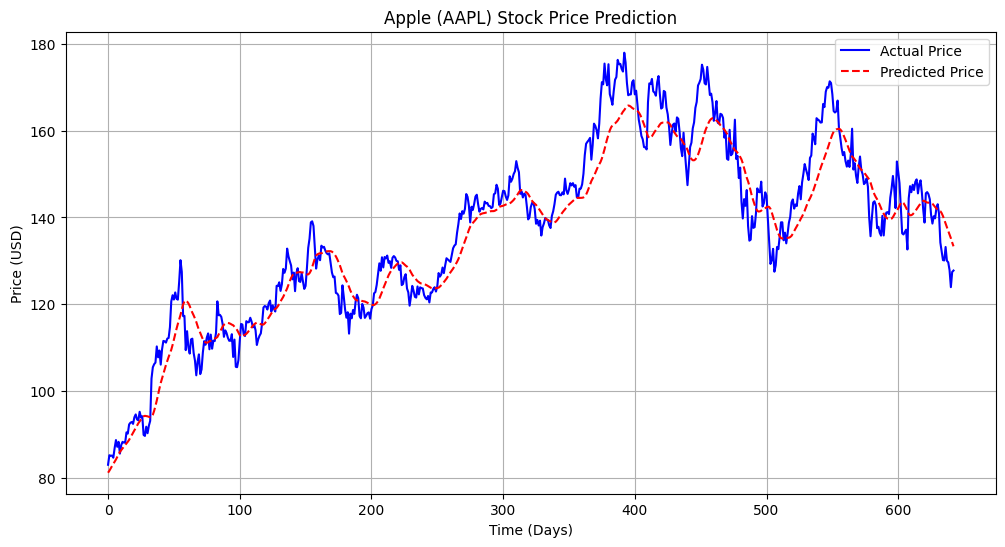

In [15]:
# 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label='Actual Price', color='blue')
plt.plot(test_predict_real, label='Predicted Price', color='red', linestyle='--')
plt.title('Apple (AAPL) Stock Price Prediction')
plt.xlabel('Time (Days)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()